In [2]:
import torch
import torch.nn as nn
import struct
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from torchvision import datasets
from torch.utils.data import DataLoader
import numpy as np
from tqdm import tqdm
import torch.nn.functional as F

#unsed
from PIL import Image
from IPython.display import display
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
BOTTLENECK = 20

class MainModel(nn.Module):
    def __init__(self):
        super(MainModel, self).__init__()
        #mis
        self.relu = nn.ReLU 
        #self.flatten = nn.Flatten this points to the concept of flatten func
        
        #encoder
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1)#sort du 14*14*32
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1) #sort du 7*7*64
        #flatten
        self.linear1 = nn.Linear(64*7*7, BOTTLENECK) #nd : essayer plus tarch avec une archi a (7*7*64->10->4)

        #decoder
        self.linear2 = nn.Linear(BOTTLENECK, 64*7*7)
        #unflatten
        self.convtranspose1 = nn.ConvTranspose2d(64, 32, 4, 2, 1)
        self.convtranspose2 = nn.ConvTranspose2d(32, 1, 4, 2, 1)
        #sigmoid

    def encoder(self, x):
        #entrée 28 par 28 --> sortie 2*2
        x = self.conv1(x)
        x = self.conv2(x)
        x = torch.flatten(x, 1) #was (x, 1, -1)
        x = self.linear1 (x)
        return x

    def decoder(self,x):
        x = self.linear2(x)
        x = x.view(x.size(0), 64, 7, 7)
        x = self.convtranspose1(x)
        x = self.convtranspose2(x)
        x = torch.sigmoid(x)

        return x

    def forward(self,x):
        #call encoder
        x = self.encoder(x)

        #call decoder
        x = self.decoder(x)
        
        return x
        
model = MainModel().to(device)

loss = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.004)

In [4]:
#batch feeder
#2048

def map_idx3_to_tensor(file_path):
    with open(file_path, 'rb') as f :
        magic = np.frombuffer(f.read(4), dtype='>i4')[0]
        n_images = np.frombuffer(f.read(4), dtype='>i4')[0]
        rows = np.frombuffer(f.read(4), dtype='>i4')[0]
        cols = np.frombuffer(f.read(4), dtype='>i4')[0] #fichier relative
    
    data_mmap = np.memmap( #code qui plant dans le type =
        file_path,
        dtype = np.uint8, #utilise le format uint8 de numpy au lieu de celui de torch car la fonction est une func numtorch
        mode= 'r',
        shape= (n_images, rows, cols),
        offset=16
    )

#convertir en tenseur pytorch
    tensor_view = torch.from_numpy(data_mmap)

    return tensor_view 

"""
images = map_idx3_to_tensor('train-images-idx3-ubyte')
sample = images[9]"""


class DataSetImage(Dataset):
    def __init__(self, root_dir) :
        self.root_dir = root_dir
        self.data = map_idx3_to_tensor(root_dir)
            
    def __len__ (self) :
        #return la taille de la donnée
        #return len(self.image_path)
        return self.data.size(0)

    def __getitem__ (self, i):
        #load l'élégent i du dataset
        image = self.data[i] # c un élément, débile
        image = image.float() /255.0
        image = image.unsqueeze(0) #shape becomes (1, 28, 28)
        return image


#création du dataset
DataRoot = DataSetImage(root_dir='datatest/train-images.idx3-ubyte')

/tmp/ipykernel_2283104/2898393022.py:20: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  tensor_view = torch.from_numpy(data_mmap)


In [5]:
#dataloader
BATCH_SIZE = 2048
THREADNUMBER = 32

#if persistent worker true (pr aller vite en coddage vaut mieux désactiver) si tu garde tes workers et tu interromp ta boucle d'entrainement
#bah ça va mettre les thread ds un état transicaca donc faut relancer le data loader
#pin memory toujours mettre a true ça met un HLM dans paris (if paris était de la ram)
data_loader = DataLoader(DataRoot, batch_size=BATCH_SIZE, shuffle=True, num_workers=THREADNUMBER, persistent_workers= True, pin_memory= True)

LossEvolution = []


In [6]:
#train loop
epochs = 100

for epoch in range(epochs):
    print("start of epoch %i" % epoch)
    for Image in tqdm(data_loader) :
        #envoyer les images ds l'auto encoder
        #compute prediction
        Image = Image.to(device, non_blocking=True)
        prediction  = model(Image) 
        lossv = loss(prediction.squeeze(), Image.squeeze())
        optimizer.zero_grad()
        lossv.backward()
        optimizer.step()
        LossEvolution.append(lossv.item())
        

start of epoch 0


  0%|          | 0/30 [00:00<?, ?it/s]

100%|██████████| 30/30 [00:00<00:00, 47.03it/s]


start of epoch 1


100%|██████████| 30/30 [00:00<00:00, 217.25it/s]


...

100%|██████████| 30/30 [00:00<00:00, 232.17it/s]


start of epoch 98


100%|██████████| 30/30 [00:00<00:00, 231.22it/s]


start of epoch 99


100%|██████████| 30/30 [00:00<00:00, 241.53it/s]


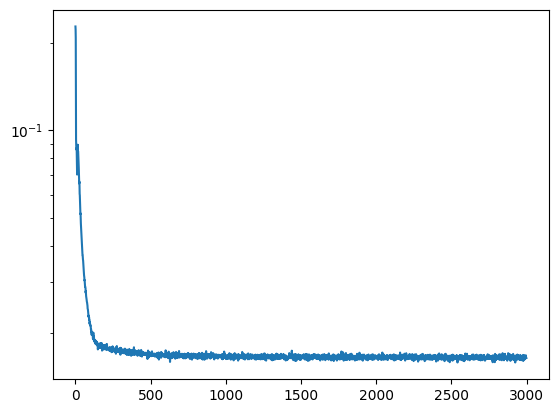

In [7]:
plt.plot(LossEvolution)
plt.yscale('log')
plt.show()

/tmp/ipykernel_2283104/456139923.py:11: UserWarning: The given buffer is not writable, and PyTorch does not support non-writable tensors. This means you can write to the underlying (supposedly non-writable) buffer using the tensor. You may want to copy the buffer to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:1581.)
  img_raw = torch.frombuffer(image_data, dtype=torch.uint8).reshape(28, 28)


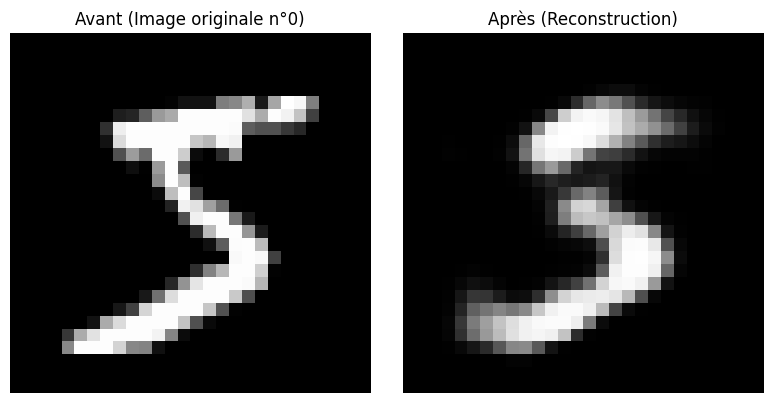

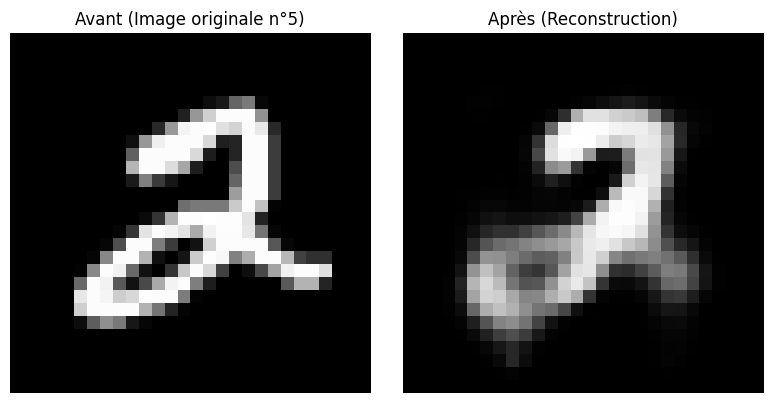

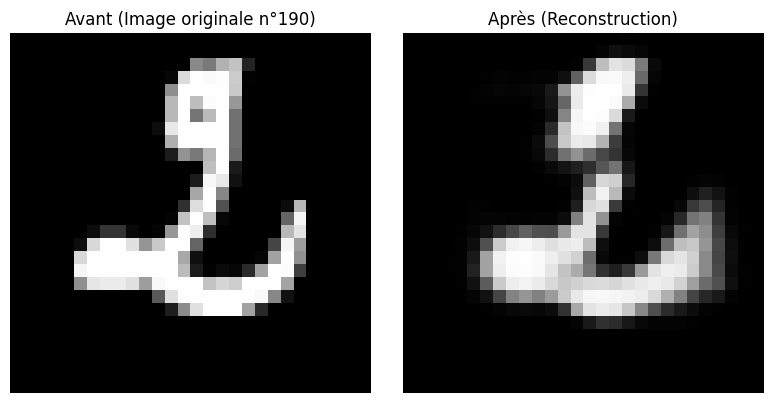

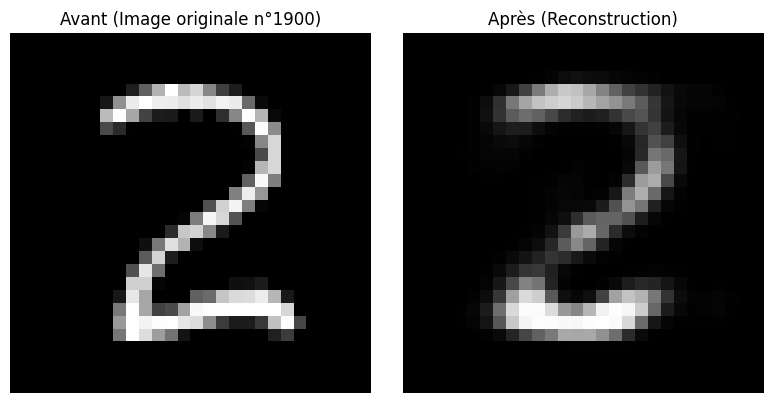

In [8]:
def compare_avant_apres(index=0):
    # 1. Extraire les données brutes (ton code)
    with open('datatest/train-images.idx3-ubyte', 'rb') as f:
        f.seek(16 + index * (28*28))
        image_data = f.read(28*28)
        if not image_data:
            print("Index hors limites !")
            return

        # Tenseur original brut [28, 28] en uint8 (0-255)
        img_raw = torch.frombuffer(image_data, dtype=torch.uint8).reshape(28, 28)

    # 2. Préparer l'image pour le modèle
    # Le modèle veut du Float entre 0 et 1, et une shape [Batch, Channel, H, W] -> [1, 1, 28, 28]
    img_input = img_raw.float() / 255.0
    img_input = img_input.unsqueeze(0).unsqueeze(0).to(device)

    # 3. Passer l'image dans le modèle (Inférence)
    model.eval() # Met le modèle en mode "évaluation" (désactive le dropout, etc.)
    with torch.no_grad(): # Désactive le calcul du gradient (économise de la RAM et accélère)
        reconstruction = model(img_input)

    # 4. Préparer les images pour l'affichage Numpy/Matplotlib
    img_originale = img_raw.cpu().numpy()
    
    # La reconstruction est entre 0.0 et 1.0, on la remet entre 0 et 255
    img_reconstruite = reconstruction.squeeze().cpu().numpy() * 255.0
    
    # Sécurité : on s'assure que les valeurs restent bien entre 0 et 255 et en entiers
    img_reconstruite = img_reconstruite.clip(0, 255).astype(np.uint8)

    # 5. Affichage côte à côte avec Matplotlib
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    
    # Image 1 : Originale
    axes[0].imshow(img_originale, cmap='gray')
    axes[0].set_title(f"Avant (Image originale n°{index})")
    axes[0].axis('off') # Cache les axes X et Y
    
    # Image 2 : Reconstruite
    axes[1].imshow(img_reconstruite, cmap='gray')
    axes[1].set_title("Après (Reconstruction)")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Remettre le modèle en mode entraînement pour la prochaine fois
    model.train()

# Teste la fonction sur les premières images !
compare_avant_apres(index=0)
compare_avant_apres(index=5)
compare_avant_apres(index=190)
compare_avant_apres(index=1900)

In [9]:
"""
Trucs a améliorer pour le score : 
cause : modele 100% plat avec aucun usage de fonctions d'activation

"empilé des convolutions et des couches linéaires pures. Mathématiquement,
un réseau sans fonctions d'activation (comme ReLU) se résume à une seule grande équation linéaire.
Il est incapable d'apprendre des formes complexes (comme des chiffres ou des objets)."

(derniere couche [convtranspose2])
l faut forcer le modèle à comprendre qu'une image ne contient que des valeurs entre 0 et 1 en utilisant une fonction Sigmoïde à la toute fin. au lieu de relu
"""


'\nTrucs a améliorer pour le score : \ncause : modele 100% plat avec aucun usage de fonctions d\'activation\n\n"empilé des convolutions et des couches linéaires pures. Mathématiquement,\nun réseau sans fonctions d\'activation (comme ReLU) se résume à une seule grande équation linéaire.\nIl est incapable d\'apprendre des formes complexes (comme des chiffres ou des objets)."\n\n(derniere couche [convtranspose2])\nl faut forcer le modèle à comprendre qu\'une image ne contient que des valeurs entre 0 et 1 en utilisant une fonction Sigmoïde à la toute fin. au lieu de relu\n'